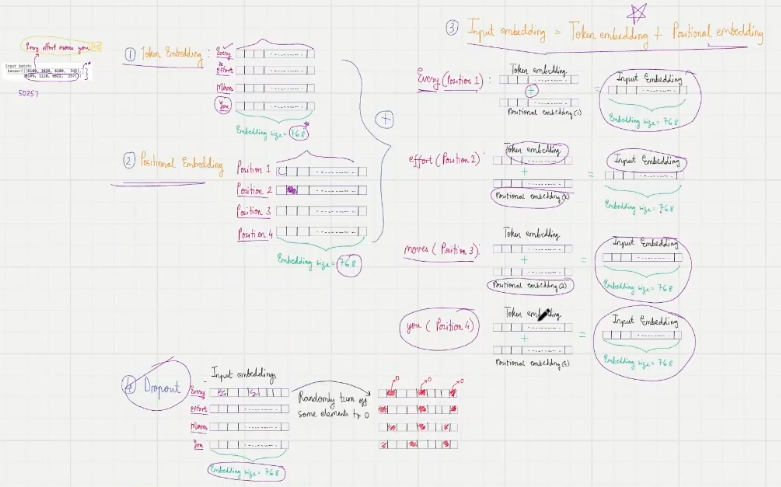

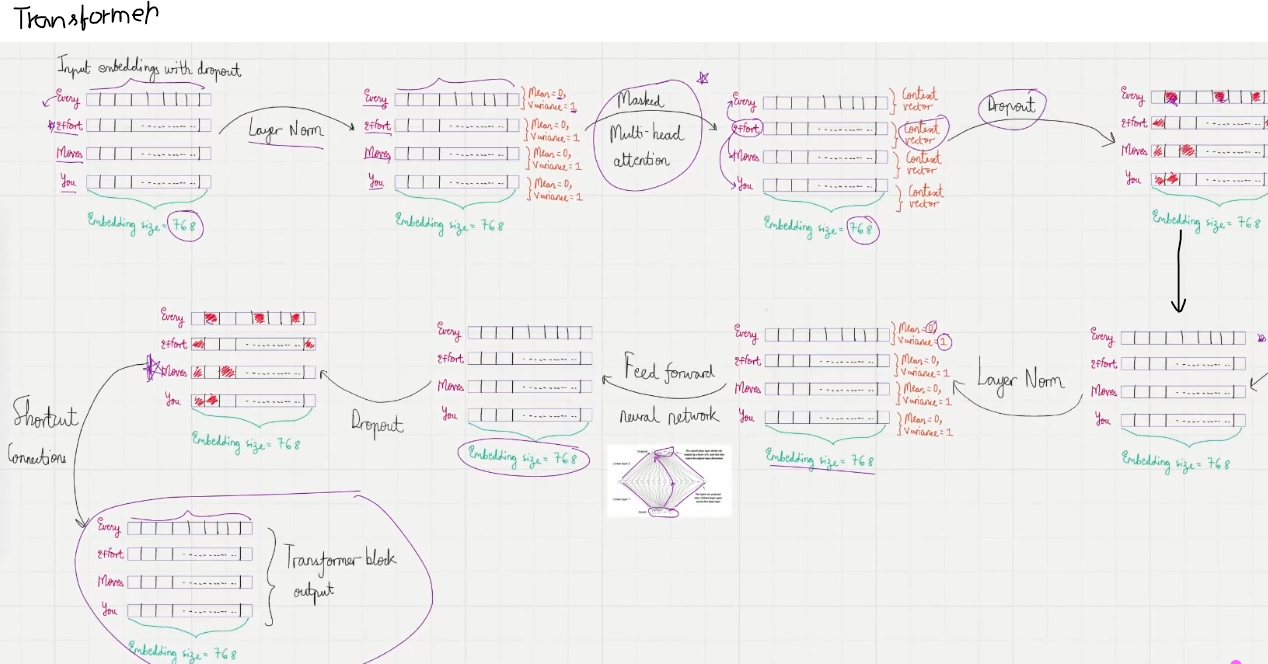

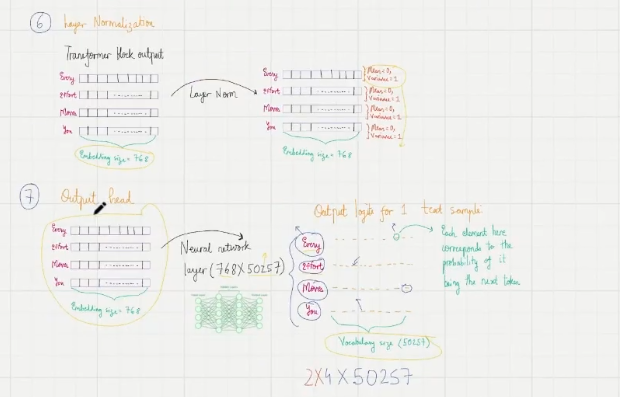

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12, #no of transformer blocks
    "drop_rate": 0.1,
    "qkv_bias": False
  }

In [ ]:
import torch
import torch.nn as nn

class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim= True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi))* (x + 0.044715 * torch.pow(x,3))))
gelu, relu = GELU(), nn.ReLU()

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
        GELU(),
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
    )
  def forward(self, x):
    return self.layers(x)

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

In [ ]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])
    self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len, device = in_idx.device))
    x = tok_embeds + pos_embeds # Shape [batch_size, num_tokens, emb_size]
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

The init constructor of this GPTModel class initializes the token and positional embedding layers using the configurations passed in via a Python dictionary, cfg.

These embedding layers are responsible for converting input token indices into dense vectors and adding positional information.

Next, the init method creates a sequential stack of TransformerBlock modules equal to the number of layers specified in cfg.

Following the transformer blocks, a LayerNorm layer is applied, standardizing the outputs from the transformer blocks to stabilize the learning process.

Finally, a linear output head without bias is defined, which projects the transformer's output into the vocabulary space of the tokenizer to generate logits for each token in the vocabulary.

The forward method takes a batch of input token indices, computes their embeddings, applies the positional embeddings, passes the sequence through the transformer blocks, normalizes the final output, and then computes the logits, representing the next token's unnormalized probabilities. We will convert these logits into tokens and text outputs in the next section.

Let's now initialize the 124 million parameter GPT model using the GPT_CONFIG_124M dictionary we pass into the cfg parameter and feed it with the batch text input we created at the beginning of this chapter:

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:", batch)
print("Output Shape:", out.shape)
print(out)

Input batch: tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output Shape: torch.Size([2, 4, 50257])
tensor([[[-1.7955e-01,  2.8515e-01, -7.6131e-01,  ..., -4.8374e-01,
          -4.2503e-01, -1.7187e-01],
         [-6.2581e-01, -3.7480e-01, -9.7020e-01,  ...,  1.9168e-01,
          -1.3234e+00, -2.7643e-01],
         [ 5.1744e-01,  1.3866e-01,  2.4886e-01,  ...,  3.5054e-01,
          -7.7531e-02, -8.0042e-02],
         [-2.5664e-01, -6.9693e-01, -9.9479e-01,  ..., -4.4732e-02,
           6.1773e-02,  1.3467e-01]],

        [[-2.2379e-01,  1.1651e-01, -9.9836e-01,  ..., -1.5730e-01,
          -4.4800e-01, -2.8646e-02],
         [-8.7227e-01, -3.9389e-01, -1.1099e+00,  ...,  3.3035e-01,
          -9.2395e-02, -1.8597e-05],
         [ 4.5988e-01, -1.4274e-01, -1.2227e-01,  ...,  2.7490e-01,
           5.8297e-02, -8.9931e-02],
         [-6.2163e-01, -4.4854e-01, -4.7675e-01,  ..., -3.6519e-01,
           3.4402e-01, -3.8154e-01]]], grad_fn=<UnsafeViewBackward0>)


As we can see, the output tensor has the shape [2, 4, 50257], since we passed in 2 input texts with 4 tokens each. The last dimension, 50,257, corresponds to the vocabulary size of the tokenizer. In the next section, we will see how to convert each of these 50,257- dimensional output vectors back into tokens.

Using the numel() method, short for "number of elements," we can collect the total number of parameters in the model's parameter tensors:

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parametters: {total_params:,}")

Total number of parametters: 162,419,712


Earlier, we spoke of initializing a 124 million parameter GPT model, so why is the actual number of parameters 163 million, as shown in the preceding code output?

The reason is a concept called weight tying that is used in the original GPT-2 architecture, which means that the original GPT-2 architecture is reusing the weights from the token embedding layer in its output layer.

To understand what this means, let's take a look at the shapes of the token embedding layer and linear output layer that we initialized on the model via the GPTModel earlier:

In [ ]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


As we can see based on the print outputs, the weight tensors for both these layers have the same shape:

The token embedding and output layers are very large due to the number of rows for the 50,257 in the tokenizer's vocabulary. Let's remove the output layer parameter count from the total GPT-2 model count according to the weight tying:

In [ ]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 123,822,336


As we can see, the model is now only 124 million parameters large, matching the original size of the GPT-2 model.

Weight tying reduces the overall memory footprint and computational complexity of the model. However, in my experience, using separate token embedding and output layers results in better training and model performance; hence, we are using separate layers in our GPTModel implementation. The same is true for modern LLMs.

Compute the memory requirements of the 163 million parameters in our GPTModel object:


In [ ]:
total_size_bytes = total_params * 4 #A
total_size_mb = total_size_bytes / (1024 * 1024) #B
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 619.58 MB


In conclusion, by calculating the memory requirements for the 163 million parameters in our GPTModel object and assuming each parameter is a 32-bit float taking up 4 bytes, we find that the total size of the model amounts to 621.83 MB, illustrating the relatively large storage capacity required to accommodate even relatively small LLMs.

In this section, we implemented the GPTModel architecture and saw that it outputs numeric tensors of shape [batch_size, num_tokens, vocab_size]. In the next section, we will write the code to convert these output tensors into text.

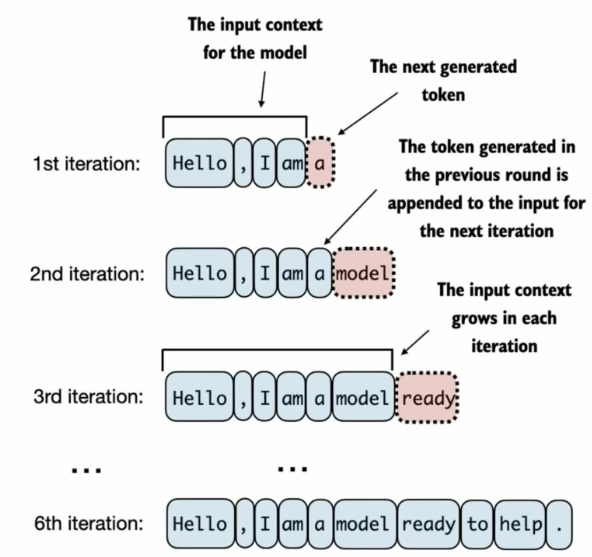

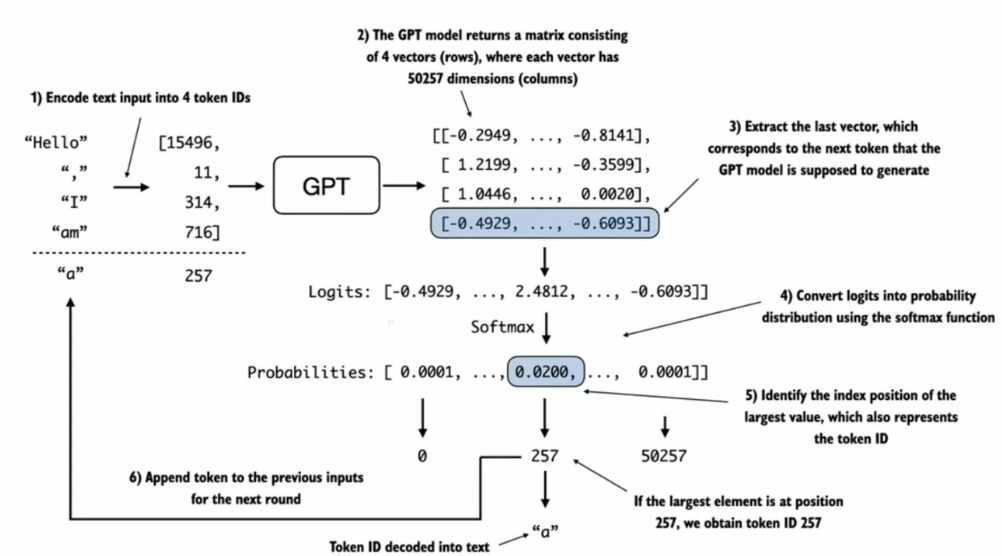

Figure below Illustrates the process of generating one token ID at a time

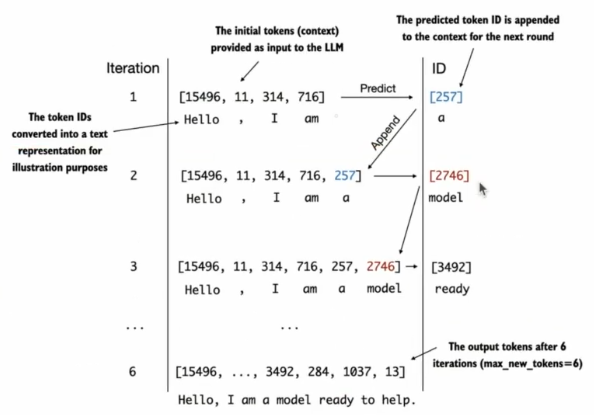

In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
  # idx is (batch, n_tokens) array of indices in the current context
  #input batch: Input batch: tensor([[6109, 3626, 6100,  345],
        #[6109, 1110, 6622,  257]])

  for _ in range(max_new_tokens):
    # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        # if current context is like [1,2,3,4,5,6,7,8,8,12,34] and the context size is like 5. Then it checks if the no of tokens are equal to context size or not. if it exceeds the context size it takes the last 5 elements from the token [7,8,8,12,34].
    idx_cond = idx[:, -context_size:]

    #Get the predictions
    with torch.no_grad(): #torch.no_grad-> during testing we only want predictions, not training
      logits = model(idx_cond) #batch, n_tokens, vocab_size

    #Focus only on the last time step
    #(batch, n_tokens, vocab_size) becomes (batch, vocab_size)
    logits = logits[:, -1, :]

    #Apply softmax to get probabilities
    probas = torch.softmax(logits, dim =-1) #(batch, vocab_size)

    #Get the idx of the vocab entry with the highest probability value
    idx_next = torch.argmax(probas, dim=-1, keepdim=True) #(batch, 1)

    #Append sampled index to the running sequence
    idx = torch.cat((idx, idx_next), dim=1) #(batch, n_tokens + 1)

  return idx

In the preceeding code, the generate_text_simple function, we use a softmax function to convert the logits into a probability distribution from which we identify the position with the highest value via torch.argmax.

The softmax function is monotonic, meaning it preserves the order of its inputs when transformed into outputs.

So, in practice, the softmax step is redundant since the position with the highest score in the softmax output tensor is the same position in the logit tensor.

In other words, we could apply the torch.argmax function to the logits tensor directly and get identical results.

However, we coded the conversion to illustrate the full process of transforming logits to probabilities, which can add additional intuition, such as that the model generates the most likely next token, which is known as greedy decoding.

In the next chapter, when we will implement the GPT training code, we will also introduce additional sampling techniques where we modify the softmax outputs such that the model doesn't always select the most likely token, which introduces variability and creativity in the generated text.

Try out the generate_text_simple function with the "Hello, I am" context as model input

First, we encode the input context into token IDs:

In [ ]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0) #a
print(encoded_tensor)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
tensor([[15496,    11,   314,   716]])
encoded_tensor.shape: torch.Size([1, 4])


Next, we put the model into .eval() mode, which disables random components like dropout, which are only used during training, and use the generate_text_simple function on the encoded input tensor:

We disable dropout since we are not training the model

In [ ]:
model.eval()
#model = GPTModel(GPT_CONFIG_124M)
out = generate_text_simple(
    model = model,
    idx = encoded_tensor,
    max_new_tokens = 6,
    context_size = GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 13240, 11381,  4307,  7640, 16620, 34991]])
Output length: 10


Using the .decode methodd of the tokenizer, we can convert the IDs back into text:

In [ ]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Laur inhab DistrinetalkQueue


As we can see, based on the preceding output, the model generated gibberish, which is not at all coherent text.

What happened?

The reason why the model is unable to produce coherent text is that we haven't trained it yet.

So far, we just implemented the GPT architecture and initialized a GPT model instance with initial random weights.

In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();

We reduce the context length (context_length) of only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens

This is so that more readers will be able to follow and execute the code examples on their laptop computer

Next, we use the generate_text_simple function from the previous chapter to generate text.

In addition, we define two convenience functions, text_to_token_ids and token_ids_to_text, for converting between token and text representations that we use throughout this chapter

In [ ]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


As we can see above, the model does not produce good text because it has not been trained yet

How do we measure or capture what "good text" is, in a numeric form, to track it during training?

The next subsection introduces metrics to calculate a loss metric for the generated outputs that we can use to measure the training progress

The next chapters on finetuning LLMs will also introduce additional ways to measure model quality

# Calculating the text generation loss: cross-entropy and perplexity

Suppose we have an inputs tensor containing the token IDs for 2 training examples (rows)

Corresponding to the inputs, the targets contain the desired token IDs that we want the model to generate

Notice that the targets are the inputs shifted by 1 position, as explained in chapter 2 when we implemented the data loader

In [ ]:
inputs = torch.tensor([[16833, 3626, 6100], [40,1107, 588]])  # ["every effort moves", "I really like"]

targets = torch.tensor([[3626, 6100, 345], [1107, 588, 11311]])  # [" effort moves you", " really like chocolate"]

Feeding the inputs to the model, we obtain the logits vector for the 2 input examples that consist of 3 tokens each

Each of the tokens is a 50,257-dimensional vector corresponding to the size of the vocabulary

Applying the softmax function, we can turn the logits tensor into a tensor of the same dimension containing probability scores

In [ ]:
with torch.no_grad():
  logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


As discussed in the previous chapter, we can apply the argmax function to convert the probability scores into predicted token IDs.

The softmax function above produced a 50,257-dimensional vector for each token; the argmax function returns the position of the highest probability score in this vector, which is the predicted token ID for the given token.

Since we have 2 input batches with 3 tokens each, we obtain 2 by 3 predicted token IDs

In [ ]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:", token_ids)

Token IDs: tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


If we decode these tokens, we find that these are quite different from the tokens we want the model to predict, namely the target tokens.

That's because the model wasn't trained yet.

To train the model, we need to know how far it is away from the correct predictions (targets)

In [ ]:
print(f"Target batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Output batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Target batch 1:  effort moves you
Output batch 1:  Armed heNetflix


Both the above Target and Output is irrelavent. This is because we did not train the model with loss functions. so now we are going to train the model with loss function.

# Cross-entropy loss

The token probabilities corresponding to the target indices are as follows:

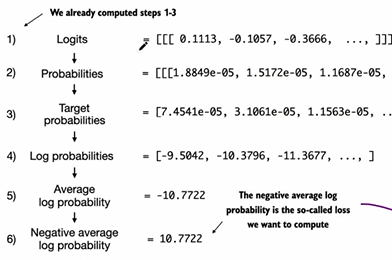

The final answer is the Cross Entropy Loss:
It measures the difference between 2 probability distribution.

In [ ]:
text_idx = 0
target_probas_1 = probas[text_idx, [0,1,2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0,1,2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


We want to maximize all these values, bringing them close to a probability of 1.

In mathematical optimization, it is easier to maximize the logarithm of the probability score than the probability score itself.

In [ ]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


Next, we compute the average log probability:

In [ ]:
#Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


The goal is to make this average log probability as large as possible by optimizing the model weights.

Due to the log, the largest possible value is 0, and we are currently far away from 0.

In deep learning, instead of maximizing the average log-probability, it's a standard convention to minimize the negative average log-probability value; in our case, instead of maximizing -10.7722 so that it approaches 0, in deep learning, we would minimize 10.7722 so that it approaches 0.

The value negative of -10.7722, i.e., 10.7722, is also called cross-entropy loss in deep learning.

In [ ]:
neg_avg_log_probas = avg_log_probas *-1
print(neg_avg_log_probas)

tensor(10.7940)


PyTorch already implements a cross_entropy function that carries out the previous steps

Before we apply the cross_entropy function, let's check the shape of the logits and targets

In [ ]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


For the cross_entropy function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

In [ ]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


Note that the targets are the token IDs, which also represent the index positions in the logits tensors that we want to maximize.

The cross_entropy function in PyTorch will automatically take care of applying the softmax and log-probability computation internally over those token indices in the logits that are to be maximized

In [ ]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


# Perplexity

A concept related to the cross-entropy loss is the perplexity of an LLM.

The perplexity is simply the exponential of the cross-entropy loss.

In [ ]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step (in the example above, that'd be 48,725 words or tokens).

In other words, perplexity provides a measure of how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset.

Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution



# Calculating the training and validation set losses

We use a relatively small dataset for training the LLM (in fact, only one short story)

The reasons are:

You can run the code examples in a few minutes on a laptop computer without a suitable GPU.

The training finishes relatively fast (minutes instead of weeks), which is good for educational purposes.

We use a text from the public domain, which can be included in this GitHub repository without violating any usage rights or bloating the repository size.

For example, Llama-2 7B required 184,320 GPU hours on A100 GPUs to be trained on 2 trillion tokens

At the time of this writing, the hourly cost of an 8xA100 cloud server at AWS is approximately 30 dollars.

So, via an off-the-envelope calculation, training this LLM would cost 184,320 / 8 * 30 = 690,000 dollars

In [ ]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://github.com/rasbt/LLMs-from-scratch/blob/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

A quick check that the text loaded ok by printing the first and last 100 words

In [ ]:
print(text_data[:99])







<!DOCTYPE html>
<html
  lang="en"
  
  data-color-mode="auto" data-light-theme="light" data-d


In [ ]:
print(text_data[-99:])

ssertive" class="sr-only mt-n1" aria-live="assertive" aria-atomic="true"></div>
  </body>
</html>




In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 323808
Tokens: 128877


With 5,145 tokens, the text is very short for training an LLM, but again, it's for educational purposes (we will also load pretrained weights later).

Next, we divide the dataset into a training and a validation set and use the data loaders from chapter 2 to prepare the batches for LLM training.

Since we train the LLM to predict the next word in the text, the targets look the same as these inputs, except that the targets are shifted by one position

# Implementing the DataLoader:

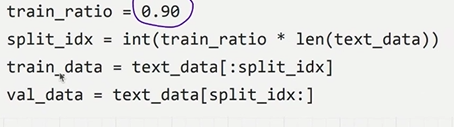

In [ ]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
  def __init__(self, txt, tokenizer, max_length, stride):
    self.input_ids = []
    self.target_ids = []

    #tokenize the entire text
    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    #Use a sliding window to chunk the book into overlapping sequence of max_length
    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i:i + max_length]
      target_chunk = token_ids[i + 1: i + max_length + 1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]

def create_dataloader_V1(txt, batch_size=4, max_length = 256, stride=128, shuffle=True,drop_last=True, num_workers=0):

  #initialize the tokenizer
  tokenizer = tiktoken.get_encoding("gpt2")

  #create dataset
  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  #create dataloader
  dataloader = DataLoader(dataset, batch_size= batch_size, shuffle = shuffle, drop_last=drop_last, num_workers=num_workers)

  return dataloader

In [ ]:
#train/validate ratio

train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_V1(train_data, batch_size = 2, max_length=GPT_CONFIG_124M["context_length"],
                                    stride=GPT_CONFIG_124M["context_length"], drop_last=True,
                                    shuffle=True, num_workers=0)

val_loader = create_dataloader_V1(val_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"],
                                  stride= GPT_CONFIG_124M["context_length"], drop_last=False,
                                  shuffle=False, num_workers=0)

In [ ]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

We use a relatively small batch size to reduce the computational resource demand, and because the dataset is very small to begin with.

Llama 2 7B was trained with a batch size of 1024, for example.

To check that the data was loaded correctly:

In [ ]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

print(len(train_loader))
print(len(val_loader))


Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256])

# Here is the GPT Model class we coded earlier. We will need this

In [ ]:
# class GPTModel(nn.Module):
#     def __init__(self, cfg):
#         super().__init__()
#         self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
#         self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
#         self.drop_emb = nn.Dropout(cfg["drop_rate"])

#         self.trf_blocks = nn.Sequential(
#             *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

#         self.final_norm = LayerNorm(cfg["emb_dim"])
#         self.out_head = nn.Linear(
#             cfg["emb_dim"], cfg["vocab_size"], bias=False
#         )

#     def forward(self, in_idx):
#         batch_size, seq_len = in_idx.shape
#         tok_embeds = self.tok_emb(in_idx)
#         pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
#         x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
#         x = self.drop_emb(x)
#         x = self.trf_blocks(x)
#         x = self.final_norm(x)
#         logits = self.out_head(x)
#         return logits

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

Next, we implement a utility function to calculate the cross-entropy loss of a given batch.

In addition, we implement a second utility function to compute the loss for a user-specified number of batches in a data loader.

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch, target_batch = input_batch.to(device), target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
  return loss

def calc_loss_loader(data_loader, model, device, num_batches = None):
  total_loss =0.
  if len(data_loader) ==0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    # Reduce the number of batches to match the total number of batches in the data loader
    # if num_batches exceeds the number of batches in the data loader
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      total_loss += loss.item()
    else:
      break
  return total_loss/num_batches

If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code.

Via the device setting, we ensure that the data is loaded onto the same device as the LLM model.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Note:
# Uncommenting the following lines will allow the code to run on Apple Silicon chips, if applicable,
# which is approximately 2x faster than on an Apple CPU (as measured on an M3 MacBook Air).
# However, the resulting loss values may be slightly different.

#if torch.cuda.is_available():
#    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
#else:
#    device = torch.device("cpu")
#
# print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

ValueError: Expected input batch_size (960) to match target batch_size (8).

#** TRAINING LOOP FOR THE LLM-PRE-TRAINING**

---



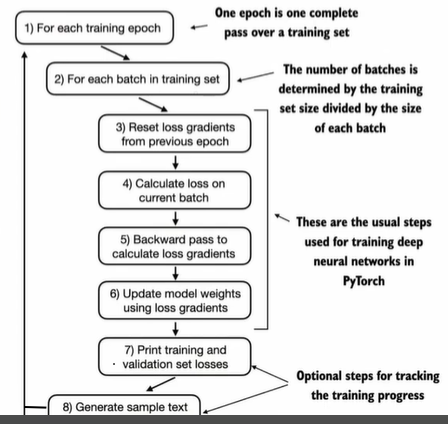

In [ ]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

Step 1: Initialize lists to track losses and tokens seen

Step 2: Start the main training loop

Step 3: Reset loss gradients from previous batch iteration

Step 4: Calculate loss gradients

Step 5: Update model weights using loss gradients

Step 6: Optional evaluation step

Step 7: Print a sample text after each epoch

In [ ]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

The evaluate_model function calculates the loss over the training and validation set while ensuring the model is in evaluation mode with gradient tracking and dropout disabled when calculating the loss over the training and validation sets

In [ ]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

The generate_and_print_sample function is a convenience function that we use to track whether the model improves during the training.

In particular, the generate_and_print_sample function takes a text snippet (start_context) as input, converts it into token IDs, and feeds it to the LLM to generate a text sample using the generate_text_simple function we used earlier

Let's see this all in action by training a GPTModel instance for 10 epochs using an AdamW optimizer and the train_model_simple function we defined earlier.

In [ ]:
# Note:
# Uncomment the following code to calculate the execution time
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

As we can see, based on the results printed during the training, the training loss improves drastically, starting with a value of 9.781 and converging to 0.391.

The language skills of the model have improved quite a lot. In the beginning, the model is only able to append commas to the start context ("Every effort moves you,,,,,,,,,,,,") or repeat the word "and".

At the end of the training, it can generate grammatically correct text.

Similar to the training set loss, we can see that the validation loss starts high (9.856) and decreases during the training.

However, it never becomes as small as the training set loss and remains at 6.372 after the 10th epoch.

Let's create a simple plot that shows the training and validation set losses side by side

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

Both the training and validation losses start to improve for the first epoch. However, the losses start to diverge past the second epoch.

This divergence and the fact that the validation loss is much larger than the training loss indicate that the model is overfitting to the training data.

We can confirm that the model memorizes the training data verbatim by searching for the generated text snippets, such as "quite insensible to the irony" in the "The Verdict" text file.

This memorization is expected since we are working with a very, very small training dataset and training the model for multiple epochs.

Usually, it's common to train a model on a much, much larger dataset for only one epoch.

# Temperature Scaling in LLM

# DECODING STRATEGIES TO CONTROL RANDOMNESS

First, we briefly revisit the generate_text_simple function from the previous chapter that we used inside the generate_and_print_sample earlier in this chapter.

Then, we will cover two techniques, temperature scaling, and top-k sampling, to improve this function.

We begin by transferring the model back from the GPU to the CPU since inference with a relatively small model does not require a GPU. Also, after training, we put the model into evaluation model to turn off random components such as dropout:

In [ ]:
model.to("cpu")
model.eval()

Next, Plug the GPTModel instance (model) into the generate_text_simple function, which uses the LLM to generate one token at a time:

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens = 25,
    context_size = GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

***DECODING STRATEGY 1: TEMPERATURE SCALING***

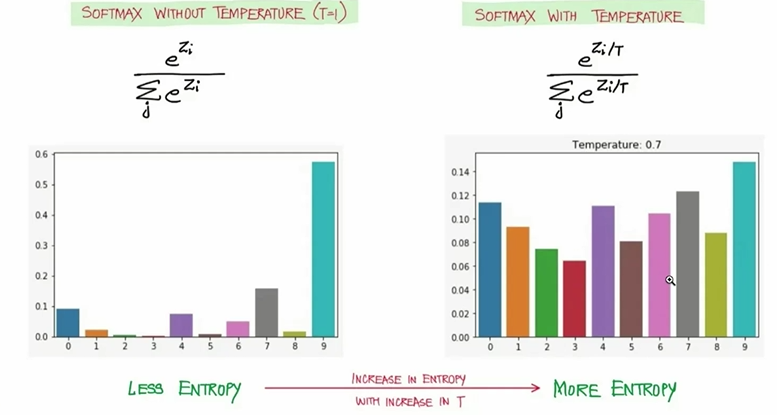

Previously, inside the generate_text_simple function, we always sampled the token with the highest probability as the next token using torch.argmax, also known as greedy decoding.

To generate text with more variety, we can replace the argmax with a function that samples from a probability distribution (here, the probability scores the LLM generates for each vocabulary entry at each token generation step).

To illustrate the probabilistic sampling with a concrete example, let's briefly discuss the next-token generation process using a very small vocabulary for illustration purposes:

In [ ]:
vocab = {"closer": 0,
         "every": 1,
         "effort": 2,
         "forward": 3,
         "inches": 4,
         "moves": 5,
         "pizza": 6,
         "toward": 7,
         "you": 8,
}

inverse_vocab = {v:k for k,v in vocab.items()}

Next, assume the LLM is given the start context "every effort moves you" and generates the following next-token logits:

In [ ]:
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

As discussed in the previous chapter, inside the generate_text_simple, we convert the logits into probabilities via the softmax function and obtain the token ID corresponding the generated token via the argmax function, which we can then map back into text via the inverse vocabulary:

In [ ]:
probas = torch.softmax(next_token_logits, dim=0)
print(probas)

next_token_id = torch.argmax(probas).item()
print(next_token_id)
print(inverse_vocab[next_token_id])

To implement a probabilistic sampling process, we can now replace the argmax with the multinomial function in PyTorch:

In [ ]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

The printed output is "forward" just like before. What happened? The multinomial function samples the next token proportional to its probability score.

In other words, "forward" is still the most likely token and will be selected by multinomial most of the time but not all the time.

To illustrate this, let's implement a function that repeats this sampling 1000 times:

In [ ]:
def print_sampled_tokens(probas):
  torch.manual_seed(123) #manual seed for reproducibility
  sample = [torch.multinomial(probas, num_samples=1). item() for i in range(1_000)]
  sampled_ids = torch.bincount(torch.tensor(sample))
  for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

As we can see based on the output, the word "forward" is sampled most of the time (582 out of 1000 times), but other tokens such as "closer", "inches", and "toward" will also be sampled some of the time.

This means that if we replaced the argmax function with the multinomial function inside the generate_and_print_sample function, the LLM would sometimes generate texts such as "every effort moves you toward", "every effort moves you inches", and "every effort moves you closer" instead of "every effort moves you forward".

We can further control the distribution and selection process via a concept called temperature scaling, where temperature scaling is just a fancy description for dividing the logits by a number greater than 0:

Temperatures greater than 1 result in more uniformly distributed token probabilities, and Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions.

Let's illustrate this by plotting the original probabilities alongside probabilities scaled with different temperature values:

In [ ]:
def softmax_with_temperature(logits, temperature):
  scaled_logits = logits/temperature
  return torch.softmax(scaled_logits, dim=0)

#Temperature values
temperatures = [1, 0.1,5] # Original, higher confidence, and lower confidence

# calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

In [ ]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

A temperature of 1 divides the logits by 1 before passing them to the softmax function to compute the probability scores.

In other words, using a temperature of 1 is the same as not using any temperature scaling.

In this case, the tokens are selected with a probability equal to the original softmax probability scores via the multinomial sampling function in PyTorch.

Applying very small temperatures, such as 0.1, will result in sharper distributions such that the behavior of the multinomial function selects the most likely token (here: "forward") almost 100% of the time, approaching the behavior of the argmax function.

Vice versa, a temperature of 5 results in a more uniform distribution where other tokens are selected more often.

This can add more variety to the generated texts but also more often results in nonsensical text.

For example, using the temperature of 5 results in texts such as "every effort moves you pizza" about 4% of the time.

# DECODING STRATEGY 2: Top-k sampling

In the previous section, I implemented a probabilistic sampling approach coupled with temperature scaling to increase the diversity of the outputs.

Saw that higher temperature values result in more uniformly distributed next-token probabilities, which result in more diverse outputs as it reduces the likelihood of the model repeatedly selecting the most probable token.

This method allows for exploring less likely but potentially more interesting and creative paths in the generation process.

However, One downside of this approach is that it sometimes leads to grammatically incorrect or completely nonsensical outputs such as "every effort moves you pizza".

In this section, I introduce another concept called top-k sampling, which, when combined with probabilistic sampling and temperature scaling, can improve the text generation results.

In top-k sampling, we can restrict the sampled tokens to the top-k most likely tokens and exclude all other tokens from the selection process by masking their probability scores.

In [ ]:
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

In [ ]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Subsequently, we apply PyTorch's where function to set the logit values of tokens that are below the lowest logit value within our top-3 selection to negative infinity (-inf).

In [ ]:
new_logits = torch.where(condition = next_token_logits < top_logits[-1],
                         input=torch.tensor(float("-inf")), other=next_token_logits)

print(new_logits)

Lastly, we apply softmax function to turn these into next-token probabilities:

In [ ]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

***Merge Temperature Scaling and Top-k sampling***

We can now apply the temperature scaling and multinomial function for probabilistic sampling introduced in the previous section to select the next token among these 3 nonzero probability scores to generate the next token. We do this in the next section by modifying the text generation function.

The previous two subsections introduced two concepts to increase the diversity of LLMgenerated text: temperature sampling and top-k sampling. In this section, we combine and add these concepts to modify the generate_simple function we used to generate text via the LLM earlier, creating a new generate function:

**Step 1:** For-loop is the same as before: Get logits, and only focus on last time step

**Step 2:** In this new section, we filter logits with top_k sampling

**Step 3:** This is the new section where we apply temperature scaling

**Step 4:** Carry out greedy next-token selection as before when temperature scaling is disabled

**Step 5:** Stop generating early if end-of-sequence token is encountered and eos_id is specified

In [ ]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

  # For-loop is the same as before: Get logits, and only focus on last time step
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]

    # New: Filter logits with top_k sampling
    if top_k is not None:
      # Keep only top_k values
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:,-1]
      logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

    # New: Apply temperature scaling
    if temperature > 0.0:
      logits = logits / temperature

      #Apply softmax to get probabilities
      probas = torch.softmax(logits, dim=-1)   #(batch_size, context_len)

      #Sample from the distribution
      idx_next = torch.multinomial(probas, num_samples=1) #(batch_size, 1)

    # Otherwise same as before: get idx of the vocab entry with the highest logits value
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)  #(batch_size, 1)

    if idx_next == eos_id: # Stop generating early if end-of-sequence token is encountered and eos_id is specified
        break

    # Same as before: append sampled index to the running sequence
    idx = torch.cat((idx, idx_next), dim=1)  #(batch_size, num_tokens+1)

  return idx





Let's now see this new generate function in action:

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens = 15,
    context_size = GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

As we can see, the generated text is very different from the one we previously generated via the generate_simple function at the beginning of section 5.3 ("Every effort moves you know," was one of the axioms he laid...!"), which was a memorized passage from the training set.

# LOADING AND SAVING MODEL WEIGHTS IN PYTORCH

Fortunately, saving a PyTorch model is relatively straightforward.

The recommended way is to save a model's so-called state_dict, a dictionary mapping each layer to its parameters, using the torch.save function as follows:

In [ ]:
model = GPTModel(GPT_CONFIG_124M)
torch.save(model.state_dict(), "model.pth")

In the preceding code, "model.pth" is the filename where the state_dict is saved.

The .pth extension is a convention for PyTorch files, though we could technically use any file extension.

Then, after saving the model weights via the state_dict, we can load the model weights into a new GPTModel model instance as follows:

In [ ]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth"))
model.eval()

If we plan to continue pretraining a model later, for example, using the train_model_simple function we defined earlier in this chapter, saving the optimizer state is also recommended.

Adaptive optimizers such as AdamW store additional parameters for each model weight. AdamW uses historical data to adjust learning rates for each model parameter dynamically.

Without it, the optimizer resets, and the model may learn suboptimally or even fail to converge properly, which means that it will lose the ability to generate coherent text.

Using torch.save, we can save both the model and optimizer state_dict contents as follows:

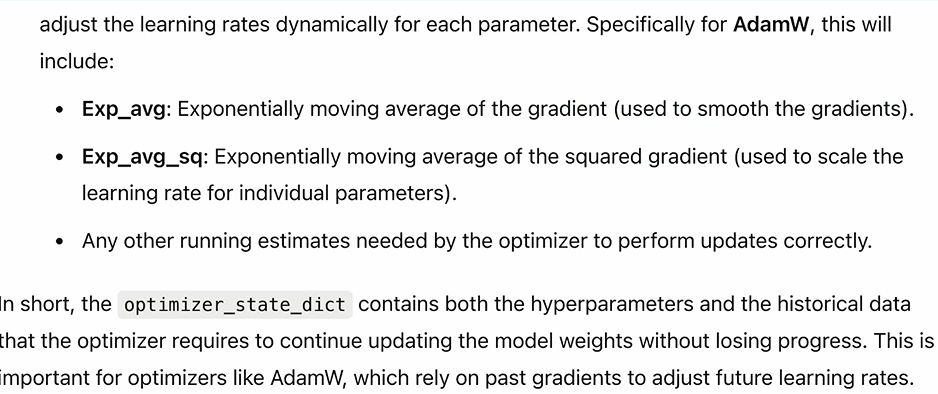

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
},
    "model_and_optimizer.pth"
)

Then, we can restore the model and optimizer states as follows by first loading the saved data via torch.load and then using the load_state_dict method:

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth")
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

# LOADING PRETRAINED WEIGHTS FROM OPENAI

Previously, for educational purposes, we trained a small GPT-2 model using a limited dataset comprising a short-story book.

This approach allowed us to focus on the fundamentals without the need for extensive time and computational resources.

Fortunately, OpenAI openly shared the weights of their GPT-2 models, thus eliminating the need to invest tens to hundreds of thousands of dollars in retraining the model on a large corpus ourselves.

In the remainder of this section, we load these weights into our GPTModel class and use the model for text generation.

Here, weights refer to the weight parameters that are stored in the .weight attributes of PyTorch's Linear and Embedding layers, for example.

We accessed them earlier via model.parameters() when training the model.

Note that OpenAI originally saved the GPT-2 weights via TensorFlow, which we have to install to load the weights in Python.

Moreover, the following code will use a progress bar tool called tqdm to track the download process, which we also have to install.

In [ ]:
!pip install tensorflow>=2.15.0 tqdm>=4.66

In [ ]:
import tensorflow as tf
import tqdm

print("TensorFlow Version", tf.__version__)
print("tqdm version", tqdm.__version__)

We download the gpt_download.py Python module directly from this chapter's online repository

We can now import the download_and_load_gpt2 function from the gpt_download.py file as follows, which will load the GPT-2 architecture settings (settings) and weight parameters (params) into our Python session:

In [ ]:
from gpt_download import download_and_load_gpt2

In [ ]:
settings, params = download_and_load_gpt2(model_size = "124M", models_dir="gpt2")

After the execution of the previous code has been completed, let's inspect the contents of settings and params:

In [ ]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Both settings and params are Python dictionaries. The settings dictionary stores the LLM architecture settings similarly to our manually defined GPT_CONFIG_124M settings.

The params dictionary contains the actual weight tensors.

Note that we only printed the dictionary keys because printing the weight contents would take up too much screen space

We can inspect these weight tensors by printing the whole dictionary via print(params) or by selecting individual tensors via the respective dictionary keys, for example, the embedding layer weights:

In [ ]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

We downloaded and loaded the weights of the smallest GPT-2 model via the download_and_load_gpt2(model_size="124M", ...) setting. However, note that OpenAI also shares the weights of larger models: "355M", "774M", and "1558M".

Above, we loaded the 124M GPT-2 model weights into Python, however we still need to transfer them into our GPTModel instance.

First, we initialize a new GPTModel instance.

Note that the original GPT model initialized the linear layers for the query, key, and value matrices in the multi-head attention module with bias vectors, which is not required or recommended; however, to be able to load the weights correctly, we have to enable these too by setting qkv_bias to True in our implementation, too.

We are also using the 1024 token context length that was used by the original GPT-2 model(s)

In [ ]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])


Careful readers may remember that we used a 256-token length earlier, but the original GPT-2 models from OpenAI were trained with a 1,024-token length, so we have to update the NEW_CONFIG accordingly:



Also, OpenAI used bias vectors in the multi-head attention module's linear layers to implement the query, key, and value matrix computations.

Bias vectors are not commonly used in LLMs anymore as they don't improve the modeling performance and are thus unnecessary.

However, since we are working with pretrained weights, we need to match the settings for consistency and enable these bias vectors:

In [ ]:
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})
gpt = GPTModel(NEW_CONFIG)
gpt.eval();

By default, the GPTModel instance is initialized with random weights for pretraining.

The last step to using OpenAI's model weights is to override these random weights with the weights we loaded into the params dictionary.

For this, we will first define a small assign utility function that checks whether two tensors or arrays (left and right) have the same dimensions or shape and returns the right tensor as trainable PyTorch parameters:

In [ ]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

Next, we define a load_weights_into_gpt function that loads the weights from the params dictionary into a GPTModel instance gpt:

Step 1: Setting the model's positional and token embedding weights to those specified in params.

Step 2: Iterate over each transformer block in the model.

Step 3: The np.split function is used to divide the attention and bias weights into three equal parts for the query, key, and value components.

Step 4: The original GPT-2 model by OpenAI reused the token embedding weights in the output layer to reduce the total number of parameters, which is a concept known as weight tying.

In [ ]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    #Query, Key, Value matrices are updated in this part
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

    #Bias term is updated where we have just replaced the "w" from above to "b".
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

    #Assign the weights downloaded from open ai to "att.out_proj.weight"
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

    #Assign the weights and biases of fully connected layer from GPT2 downloaded values and assigning it to "ff" object. Note it is done for both the layers -> layer1, layer2
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

    #Access scale and shift parameters from GPT2 values downloaded and assigning it to our gpt model class on both the normalization layer-> norm1, norm2
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])



In the load_weights_into_gpt function, we carefully match the weights from OpenAI's implementation with our GPTModel implementation.

To pick a specific example, OpenAI stored the weight tensor for the output projection layer for the first transformer block as params["blocks"][0]["attn"]["c_proj"]["w"].

In our implementation, this weight tensor corresponds to gpt.trf_blocks[b].att.out_proj.weight, where gpt is a GPTModel instance.

Developing the load_weights_into_gpt function took a lot of guesswork since OpenAI used a slightly different naming convention from ours.

However, the assign function would alert us if we try to match two tensors with different dimensions.

Also, if we made a mistake in this function, we would notice this as the resulting GPT model would be unable to produce coherent text.

Let's now try the load_weights_into_gpt out in practice and load the OpenAI model weights into our GPTModel instance gpt:

In [ ]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

If the model is loaded correctly, we can now use it to generate new text using our previous generate function:

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("I study in TU/e", tokenizer).to(device),
    max_new_tokens=50,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

We can be confident that we loaded the model weights correctly because the model can produce coherent text.

A tiny mistake in this process would cause the model to fail.

In the following chapters, we will work further with this pretrained model and fine-tune it to classify text and follow instructions.

# FINETUNING FOR CLASSIFICATION

DOWNLOADING DATASET & PREPROCESS THE DATASET

In [ ]:
import urllib.request
import ssl
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
  if data_file_path.exists():
    print(f"{data_file_path} already exists. Skipping download and extraction.")
    return

  # Create an unverified SSL context
  ssl_context = ssl._create_unverified_context()

  #Download the file
  with urllib.request.urlopen(url, context= ssl_context) as response:
    with open(zip_path, "wb") as out_file:
      out_file.write(response.read())

  #Unzipping the file
  with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extracted_path)

  #Add .tsv file extension
  original_file_path = Path(extracted_path) / "SMSSpamCollection"
  os.rename(original_file_path, data_file_path)
  print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


After executing the preceding code, the dataset is saved as a tab-separated text file, SMSSpamCollection.tsv, in the sms_spam_collection folder.

We can load it into a pandas DataFrame as follows:

In [ ]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


When we check the class distribution, we see that the data contains "ham" (i.e., "not spam") much more frequently than "spam"



In [ ]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


For simplicity, and because we prefer a small dataset for educational purposes anyway (it will make it possible to finetune the LLM faster), we subsample (undersample) the dataset so that it contains 747 instances from each class

In [ ]:
def create_balanced_dataset(df):
  #Count the instances of "spam"
  num_spam = df[df["Label"] == "spam"].shape[0]

  #Randomly sample "ham" instances to match the number of "spam" instances
  ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)

  #Combine ham "subset" with "spam"
  balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

  return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


After executing the previous code to balance the dataset, we can see that we now have equal amounts of spam and non-spam messages:

Next, we convert the "string" class labels "ham" and "spam" into integer class labels 0 and 1, respectively:

In [ ]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

This process is similar to converting text into token IDs.

However, instead of using the GPT vocabulary, which consists of more than 50,000 words, we are dealing with just two token IDs: 0 and 1.

We create a random_split function to split the dataset into three parts: 70% for training, 10% for validation, and 20% for testing.

(These ratios are common in machine learning to train, adjust, and evaluate models.)

In [ ]:
def random_split(df, train_frac, validation_frac):
  #Shuffle the entire DataFrame
  df = df.sample(frac=1, random_state=123).reset_index(drop=True)

  #Calculate split indices
  train_end = int(len(df) * train_frac)
  validation_end = train_end + int(len(df) * validation_frac)

  #Split the DataFrame
  train_df = df[:train_end]
  validation_df = df[train_end:validation_end]
  test_df = df[validation_end:]

  return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
#Test size is implied to be 0.2 as the remainder

In [ ]:
print(len(train_df))
print(len(validation_df))
print(len(test_df))

1045
149
300


Additionally, we save the dataset as CSV (comma-separated value) files, which we can reuse later:

In [ ]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index = None)
test_df.to_csv("test.csv", index=None)

So, as of now the Downloading dataset and Preprocessing the dataset is finished as of now.

# CREATING DATALOADERS

Previously, we utilized a sliding window technique to generate uniformly sized text chunks, which were then grouped into batches for more efficient model training. Each chunk functioned as an individual training instance

In the case of email spam classification, have two primary options:

(1) Truncate all messages to the length of the shortest message in the dataset or batch.

(2) Pad all messages to the length of the longest message in the dataset or batch.

Option 1 is computationally cheaper, but it may result in significant information loss if shorter messages are much smaller than the average or longest messages, potentially reducing model performance.

So, we opt for the second option, which preserves the entire content of all messages.

To implement option 2, where all messages are padded to the length of the longest message in the dataset, we add padding tokens to all shorter messages.

For this purpose, we use "<|endoftext|>" as a padding token, as discussed in chapter 2.

However, instead of appending the string "<|endoftext|>" to each of the text messages directly, we can add the token ID corresponding to "<|endoftext|>" to the encoded text

As we have seen earlier, we first need to implement a PyTorch Dataset, which specifies how the data is loaded and processed, before we can instantiate the data loaders.

For this purpose, we define the SpamDataset class.

This SpamDataset class handles several key tasks: it identifies the longest sequence in the training dataset, encodes the text messages, and ensures that all other sequences are padded with a padding token to match the length of the longest sequence.

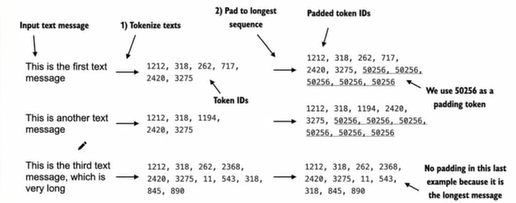

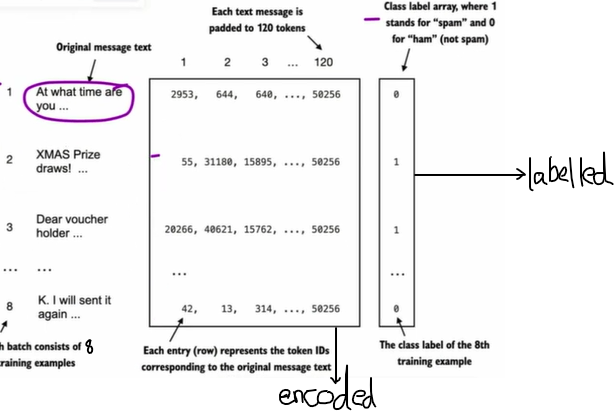

In [ ]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
  def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
    self.data = pd.read_csv(csv_file)

    #Pre-tokenize texts
    self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

    if max_length is None:
      self.max_length = self._longest_encoded_length()
    else:
      self.max_length = max_length

      #Truncate sequences if they are longer than max_length
      self.encoded_texts = [
          encoded_text[:self.max_length] for encoded_text in self.encoded_texts
      ]
    # Pad sequences to the longest sequence
    self.encoded_texts = [
        encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
        for encoded_text in self.encoded_texts
    ]

  def __getitem__(self, index):
    encoded = self.encoded_texts[index]
    label = self.data.iloc[index]["Label"]
    return (
        torch.tensor(encoded, dtype=torch.long),
        torch.tensor(label, dtype=torch.long)
    )

  def __len__(self):
    return len(self.data)

  def _longest_encoded_length(self):
    max_length = 0
    for encoded_text in self.encoded_texts:
      encoded_length = len(encoded_text)
      if encoded_length > max_length:
        max_length = encoded_length
    return max_length

Step 1: Pre-tokenize texts

Step 2: Truncate sequences if they are longer than max_length

Step 3: Pad sequences to the longest sequence

The SpamDataset class loads data from the CSV files we created earlier, tokenizes the text using the GPT-2 tokenizer from tiktoken and allows us to pad or truncate the sequences to a uniform length determined by either the longest sequence or a predefined maximum length.

This ensures each input tensor is of the same size, which is necessary to create the batches in the training data loader we implement next:

In [ ]:
train_dataset = SpamDataset(csv_file = "train.csv", max_length=None, tokenizer=tokenizer)
print(train_dataset.max_length)

120


The code outputs 120, showing that the longest sequence contains no more than 120 tokens, a common length for text messages.

It's worth noting that the model can handle sequences of up to 1,024 tokens, given its context length limit.

If your dataset includes longer texts, you can pass max_length=1024 when creating the training dataset in the preceding code to ensure that the data does not exceed the model's supported input (context) length.

Next, we pad the validation and test sets to match the length of the longest training sequence.

It's important to note that any validation and test set samples exceeding the length of the longest training example are truncated using encoded_text[:self.max_length] in the SpamDataset code we defined earlier.

This truncation is optional; you could also set max_length=None for both validation and test sets, provided there are no sequences exceeding 1,024 tokens in these sets

In [ ]:
val_dataset = SpamDataset(
    csv_file = "validation.csv", max_length = train_dataset.max_length, tokenizer = tokenizer
)

test_dataset = SpamDataset(
    csv_file = "test.csv",
    max_length = train_dataset.max_length,
    tokenizer = tokenizer
)

Using the datasets as inputs, we can instantiate the data loaders similarly to what we did earlier.

However, in this case, the targets represent class labels rather than the next tokens in the text.

For instance, choosing a batch size of 8, each batch will consist of 8 training examples of length 120 and the corresponding class label of each example.

In [ ]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers = num_workers,
    drop_last = True
)

val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = batch_size,
    num_workers = num_workers,
    drop_last = False
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    num_workers = num_workers,
    drop_last = False
)

To ensure that the data loaders are working and are indeed returning batches of the expected size, we iterate over the training loader and then print the tensor dimensions of the last batch:

In [ ]:
print("Train loader:")
for input_batch, target_batch in train_loader:
  pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions:", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions: torch.Size([8])


As we can see, the input batches consist of 8 training examples with 120 tokens each, as expected.

The label tensor stores the class labels corresponding to the 8 training examples.

Lastly, to get an idea of the dataset size, let's print the total number of batches in each dataset:

In [ ]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


This concludes the data preparation. Next, we will prepare the model for finetuning.

# INITIALIZING A MODEL WITH PRETRAINED WEIGHTS

In this section, we prepare the model we will use for the classification-finetuning to identify spam messages.

We start with initializing the pretrained model we worked with in the previous chapter

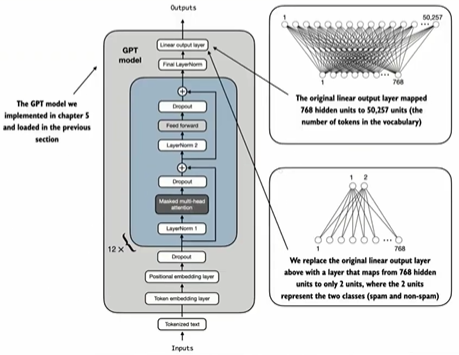

In [ ]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads":12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads":16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads":20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25}
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"dataset length {train_dataset.max_length} exceeds model's context"
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with"
    f"`max_length={BASE_CONFIG['context_length']}`"
)

Next, we import the download_and_load_gpt function from the gpt_download3.py file we downloaded earlier.

Furthermore, we also reuse the GPTModel class and load_weights_into_gpt function from chapter 5 to load the downloaded weights into the GPT model:

In [ ]:
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

from gpt_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

To ensure that the model was loaded correctly, let's double-check that it generates coherent text

In [ ]:
text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model = model,
    idx =text_to_token_ids(text_1, tokenizer),
    max_new_tokens = 15,
    context_size = BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Now, before we start finetuning the model as a spam classifier, let's see if the model can perhaps already classify spam messages by by prompting it with instructions:

In [ ]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Based on the output, it's apparent that the model struggles with following instructions.

This is anticipated, as it has undergone only pretraining and lacks instruction-finetuning, which we will explore in the upcoming chapter

The next section prepares the model for classification-finetuning

# ADDING A CLASSIFICATION HEAD

In this section, we modify the pretrained large language model to prepare it for classification-finetuning.

To do this, we replace the original output layer, which maps the hidden representation to a vocabulary of 50,257, with a smaller output layer that maps to two classes: 0 ("not spam") and 1 ("spam"),

We could technically use a single output node since we are dealing with a binary classification task.

However, this would require modifying the loss function.

Therefore, we choose a more general approach where the number of output nodes matches the number of classes.

For example, for a 3-class problem, such as classifying news articles as "Technology", "Sports", or "Politics", we would use three output nodes, and so forth.

Before we attempt to construct the modified architecture, let's print the model architecture via print(model), which prints the following:

In [ ]:
print(model)

Above, we can see the GPT architecture neatly laid out.

As discussed earlier, the GPTModel consists of embedding layers followed by 12 identical transformer blocks (only the last block is shown for brevity), followed by a final LayerNorm and the output layer, out_head.

Next, we replace the out_head with a new output layer, as illustrated in figure 6.9, that we will finetune.

To get the model ready for classification-finetuning, we first freeze the model, meaning that we make all layers non-trainable:

In [ ]:
for param in model.parameters():
  param.requires_grad = False

Then, we replace the output layer (model.out_head), which originally maps the layer inputs to 50,257 dimensions (the size of the vocabulary):

In [ ]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

Note that in the preceding code, we use BASE_CONFIG["emb_dim"], which is equal to 768 in the "gpt2-small (124M)" model, to keep the code below more general.

This means we can also use the same code to work with the larger GPT-2 model variants.

This new model.out_head output layer has its requires_grad attribute set to True by default, which means that it's the only layer in the model that will be updated during training.

This new model.out_head output layer has its requires_grad attribute set to True by default, which means that it's the only layer in the model that will be updated during training.

Additionally, we configure the last transformer block and the final LayerNorm module, which connects this block to the output layer, to be trainable

In [ ]:
for param in model.trf_blocks[-1].parameters():
  param.requires_grad = True

for param in model.final_norm.parameters():
  param.requires_grad = True

Even though we added a new output layer and marked certain layers as trainable or nontrainable, we can still use this model in a similar way to previous chapters.

For instance, we can feed it an example text identical to how we have done it in earlier chapters. For example, consider the following example text:

In [ ]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)

print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)

Then, we can pass the encoded token IDs to the model as usual:

In [ ]:
with torch.no_grad():
  outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

In earlier chapters, a similar input would have produced an output tensor of [1, 4, 50257], where 50,257 represents the vocabulary size.

As in previous chapters, the number of output rows corresponds to the number of input tokens (in this case, 4).

However, each output's embedding dimension (the number of columns) is now reduced to 2 instead of 50,257 since we replaced the output layer of the model.

Remember that we are interested in finetuning this model so that it returns a class label that indicates whether a model input is spam or not spam.

To achieve this, we don't need to finetune all 4 output rows but can focus on a single output token.

In particular, we will focus on the last row corresponding to the last output token

To extract the last output token, illustrated in figure 6.11, from the output tensor, we use the following code:

In [ ]:
print("Last output token:", outputs[:,-1,:])

Till here we havent trained out model. So to train out model we need to define the loss function and implement back propogation

Having modified the model, the next section will detail the process of transforming the last token into class label predictions and calculate the model's initial prediction accuracy.

Following this, we will finetune the model for the spam classification task in the subsequent section.

Once we have the loss function, we are ready to do back propogation and then then finetune the parameters and then we will do training and testing after that...

# CALCULATING THE CLASSIFICATION LOSS AND ACCURACY

So far in this chapter, we have prepared the dataset, loaded a pretrained model, and modified it for classification-finetuning.

Before we proceed with the finetuning itself, only one small part remains: implementing the model evaluation functions used during finetuning,

Before implementing the evaluation utilities, let's briefly discuss how we convert the model outputs into class label predictions.

In the previous chapter, we computed the token ID of the next token generated by the LLM by converting the 50,257 outputs into probabilities via the softmax function and then returning the position of the highest probability via the argmax function.

In this chapter, we take the same approach to calculate whether the model outputs a "spam" or "not spam" prediction for a given input, with the only difference being that we work with 2-dimensional instead of 50,257-dimensional outputs.

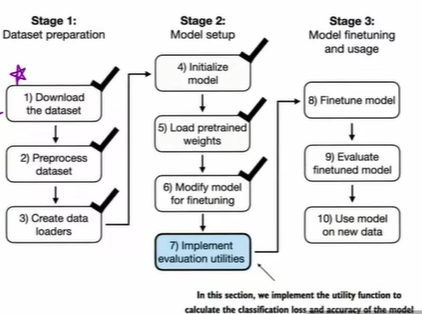

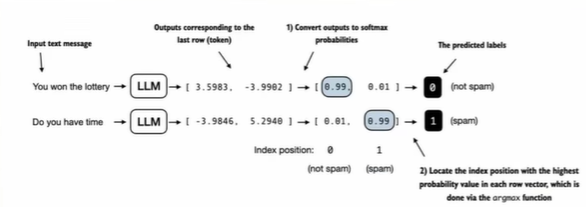

Let's consider the last token output from the previous section:

In [ ]:
print("Last output token:", outputs[:,-1,:])

We can obtain the class label via the following code:

In [ ]:
probas = torch.softmax(outputs[:,-1,:], dim=-1)
print(probas)
label = torch.argmax(probas)
print("Class label index:", label.item())

In this case, the code returns 1, meaning the model predicts that the input text is "spam."

Using the softmax function here is optional because the largest outputs directly correspond to the highest probability scores.

Hence, we can simplify the code as follows, without using softmax:

In [ ]:
logits = outputs[:,-1,:]
label = torch.argmax(logits)
print("Class label:", label.item())

This concept can be used to compute the so-called classification accuracy, which measures the percentage of correct predictions across a dataset.

To determine the classification accuracy, we apply the argmax-based prediction code to all examples in the dataset and calculate the proportion of correct predictions by defining a calc_accuracy_loader function:

In [ ]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
  model.eval()
  correct_predictions, num_examples = 0, 0

  if num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batch = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i< num_batches:
      input_batch, target_batch = input_batch.to(device), target_batch.to(device)

      with torch.no_grad():
        logits = model(input_batch)[:,-1,:] #logits of last output token
      predicted_labels = torch.argmax(logits, dim=-1)

      num_examples += predicted_labels.shape[0]
      correct_predictions += (predicted_labels == target_batch).sum().item()
    else:
      break
  return correct_predictions/num_examples

Let's use the function to determine the classification accuracies across various datasets estimated from 10 batches for efficiency:

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Note:
# Uncommenting the following lines will allow the code to run on Apple Silicon chips, if applicable,
# which is approximately 2x faster than on an Apple CPU (as measured on an M3 MacBook Air).
# As of this writing, in PyTorch 2.4, the results obtained via CPU and MPS were identical.
# However, in earlier versions of PyTorch, you may observe different results when using MPS.

#if torch.cuda.is_available():
#    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
#else:
#    device = torch.device("cpu")
#print(f"Running on {device} device.")

model.to(device) #no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) #For reproducibility due to the shuffling in the training data loader

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Train accuracy: {train_accuracy*100:.2f}")
print(f"Validation accuracy: {val_accuracy*100:.2f}")
print(f"Test accuracy: {test_accuracy*100:.2f}")

As we can see, the prediction accuracies are near a random prediction, which would be 50% in this case.

To improve the prediction accuracies, we need to finetune the model.

Classification accuracy is not a differentiable function, so we use cross entropy loss as a proxy to maximize accuracy.

This is the same cross entropy loss discussed earlier.

Accordingly, the calc_loss_batch function remains the same as in earlier, with one adjustment: we focus on optimizing only the last token, model(input_batch)[:, -1, :], rather than all tokens, model(input_batch):

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch, target_batch = input_batch.to(device), target_batch.to(device)
  logits = model(input_batch)[:,-1,:] #logits of last output token
  loss = torch.nn.functional.cross_entropy(logits, target_batch)
  return loss

We use the calc_loss_batch function to compute the loss for a single batch obtained from the previously defined data loaders. To calculate the loss for all batches in a data loader, we define the calc_loss_loader function

In [ ]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0.
  if len(data_loader) ==0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    # Reduce the number of batches to match the total number of batches in the data loader
    # if num_batches exceeds the number of batches in the data loader
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i< num_batches:
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      total_loss += loss.item()

    else:
      break
  return total_loss/num_batches

Similar to calculating the training accuracy, we now compute the initial loss for each data set:

In [ ]:
with torch.no_grad(): #disable gradient tracking for efficiency because we are not training, yet
  train_loss = calc_loss_loader(train_loader, model, device, num_batches = 5)
  val_loss = calc_loss_loader(val_loader, model, device, num_batches = 5)
  test_loss = calc_loss_loader(test_loader, model, device, num_batches = 5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Next, we will implement a training function to finetune the model, which means adjusting the model to minimize the training set loss.

Minimizing the training set loss will help increase the classification accuracy, our overall goal

Until Now, we have completed till Implementing the evaluation utilities

# FINETUNING THE MODEL ON SUPERVISED DATA

In this section, we define and use the training function to finetune the pretrained LLM and improve its spam classification accuracy.

The training loop is the same overall training loop we used earlier, with the only difference being that we calculate the classification accuracy instead of generating a sample text for evaluating the model.

The training function also closely mirrors the train_model_simple function used for pretraining the model earlier.

The only two distinctions are that we now track the number of training examples seen (examples_seen) instead of the number of tokens, and we calculate the accuracy after each epoch instead of printing a sample text:

Step 1: Set model to training mode

Step 2: Reset loss gradients from previous batch iteration

Step 3: Calculate loss gradients

Step 4: Update model weights using loss gradients

Step 5: New: track examples instead of tokens

Step 6: Optional evaluation step

Step 7: Calculate accuracy after each epoch

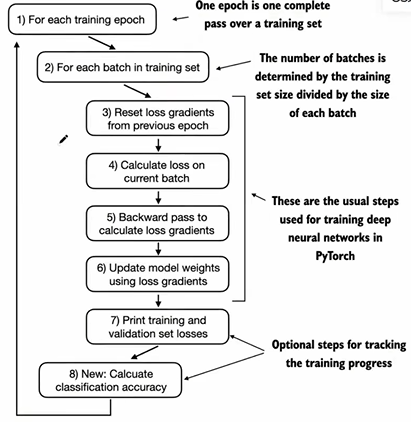

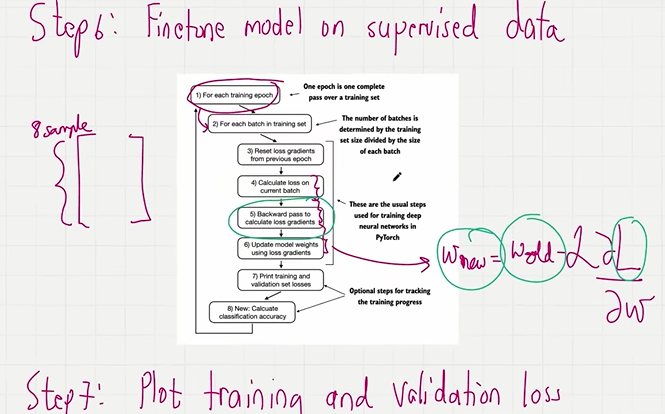

In [ ]:
#overall its the same as train_model_simple
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter):
  #ititialize lists to track losses and examples seen
  train_losses, val_losses, train_accs, val_accs = [],[],[],[]
  examples_seen, global_step = 0, -1

  #Main training loop
  for epoch in range(num_epochs):
    model.train() #set model to training mode

    for input_batch, target_batch in train_loader:
      optimizer.zero_grad() #reset loss gradient from previous batch iteration
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      loss.backward() #calculate loss gradient
      optimizer.step() #update model weights using loss gradients
      examples_seen += input_batch.shape[0] #New: track examples instead of tokens ie, 8 from [8,120]
      global_step += 1

      ##130 batches: training, eval_freq=50 --> after 50 batches are processed in each epoch, we print the training loss and validation loss

      #Optional evaluation step
      if global_step % eval_freq ==0:
        train_loss, val_loss = evaluate_model(
            model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Ep {epoch+1} (Step {global_step:06d})" f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

    #Calculate accuracy after each epoch
    train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches = eval_iter)
    val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches = eval_iter)
    print(f"Training accuracy: {train_accuracy*100:.2f}%", end="")
    print(f":Validation accuracy: {val_accuracy*100:.2f}%")
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)

  return train_losses, val_losses, train_accs, val_accs, examples_seen

The evaluate_model function used in the train_classifier_simple is the same as the one we used earlier.



In [ ]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches= eval_iter)
  model.train()
  return train_loss, val_loss

Next, we initialize the optimizer, set the number of training epochs, and initiate the training using the train_classifier_simple function.

We will discuss the choice of the the number of training epochs after we evaluated the results.

The training takes about 6 minutes on an M3 MacBook Air laptop computer and less than half a minute on a V100 or A100 GPU:

In [ ]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs=5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs = num_epochs, eval_freq=50, eval_iter=5)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

We then use matplotlib to plot the loss function for the training and validation set:

In [ ]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
  fig, ax1 = plt.subplots(figsize=(5,3))

  #plot training and validation loss against epochs
  ax1.plot(epochs_seen, train_values, label=f"Training {label}")
  ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel(label.capitalize())
  ax1.legend()

  #Create a second x-axis for examples seen
  ax2 = ax1.twiny() #create a second x-axis that shares teh same y-axis
  ax2.plot(examples_seen, train_values, alpha = 0) #invisible plot for aligning ticks
  ax2.set_xlabel("Examples seen")

  fig.tight_layout() #adjust layout to make room
  plt.savefig(f"{label}-plot.pdf")
  plt.show()

In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

As we can see based on the sharp downward slope, the model is learning well from the training data, and there is little to no indication of overfitting; that is, there is no noticeable gap between the training and validation set losses.

Using the same plot_values function, let's now also plot the classification accuracies:

In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

Based on the accuracy plot in figure 6.17, the model achieves a relatively high training and validation accuracy after epochs 4 and 5.

However, it's important to note that we previously set eval_iter=5 when using the train_classifier_simple function, which means our estimations of training and validation performance were based on only 5 batches for efficiency during training.

Now, we will calculate the performance metrics for the training, validation, and test sets across the entire dataset by running the following code, this time without defining the eval_iter value:

In [ ]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

The training and test set performances are almost identical.

A slight discrepancy between the training and test set accuracies suggests minimal overfitting of the training data.

Typically, the validation set accuracy is somewhat higher than the test set accuracy because the model development often involves tuning hyperparameters to perform well on the validation set, which might not generalize as effectively to the test set.

This situation is common, but the gap could potentially be minimized by adjusting the model's settings, such as increasing the dropout rate (drop_rate) or the weight_decay parameter in the optimizer configuration.

Till here we have completed till 9) Evaluate finetuned model.

Next we will go for 10) Use model on new data

# USING THE LLM AS A SPAM CLASSIFIER

After finetuning and evaluating the model in the previous sections, we are now in the final stage of this chapter: using the model to classify spam messages.

Finally, let's use the finetuned GPT-based spam classification model.

The following classify_review function follows data preprocessing steps similar to those we used in the SpamDataset implemented earlier in this chapter.

And then, after processing text into token IDs, the function uses the model to predict an integer class label, similar to what we have implemented earlier, and then returns the corresponding class name:

Step 1: Prepare inputs to the model

Step 2: Truncate sequences if they too long

Step 3: Pad sequences to the longest sequence

Step 4: Add batch dimension

Step 5: Model inference without gradient tracking

Step 6: Logits of the last output token

Step 7: Return the classified result

In [ ]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]

    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

Lets try this classify_review function on an example text:

In [ ]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length = train_dataset.max_length
))

The resulting model predicts as "Spam" correctly

In [ ]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

Also, here, the model makes a correct prediction and returns a "not spam" label.

Finally, let's save the model in case we want to reuse the model later without having to train it again using the torch.save method

In [ ]:
torch.save(model.state_dict(), "review_classifier.pth")

Once saved, the model can be loaded as follows:

In [ ]:
model_state_dict = torch.load("review_classifier.pth")
model.load_state_dict(model_state_dict)

# INSTRUCTION FINE-TUNING

## STEP 1: PREPARING DATASET

In this section, we download and format the instruction dataset for instruction finetuning a pretrained LLM in this chapter. The dataset consists of 1100 instruction-response pairs.

The following code implements and executes a function to download this dataset, which is a relatively small file, only 204 KB in size, in JSON format. JSON, or JavaScript Object Notation, mirrors the structure of Python dictionaries, providing a simple structure for data interchange that is both human-readable and machine-friendly.

In [ ]:
import json
import os
import urllib
import ssl

def download_and_load_file(file_path, url):
    ssl_context = ssl.create_default_context()
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url, context=ssl_context) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


file_path = "instruction-data.json"
url = ("https://github.com/rasbt/LLMs-from-scratch/blob/main/ch07/01_main-chapter-code/instruction-data.json")

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))


The data list , which we loaded from the JSON file contains the 1100 entries of the instruction dataset.

Let's print one of the entries to see how each entry is structured:

In [ ]:
print("Exmaple entry:\n", data[50])

In [ ]:
print("Another Entry:\n", data[999])

Here in LLM's there is a specific format with which we give the prompt. One of it is Stanford Alpaca and another one is phi-3 Microsoft model. Most used format is Stanford Alpaca

## CONVERTING INSTRUCTIONS INTO ALPACA FORMAT

In [ ]:
def format_input(entry):
  instruction_text = (
      f"Below is an instruction that describes a task."
      f"Write a response that appropriately completes teh request."
      f"\n\n### Instruction:\n{entry['instruction']}"
  )

  input_text = f"\n\n### Input:\n{entry['input']}" if entry ["input"] else ""

  return instruction_text + input_text

This format_input function takes a dictionary entry as input and constructs a formatted string.

Let's test it to dataset entry data[50], which to looked at earlier:

In [ ]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Note that the format_input skips the optional ### Input: section if the 'input' field is empty, which we can test out by applying the format_input function to entry data[999] that we inspected earlier:

In [ ]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

## SPLITTING DATASET INTO TRAIN-TEST-VALIDATION

In [ ]:
train_portion = int(len(data) *0.85) #85% on training
test_portion = int(len(data) *0.1) #10% on testing
val_portion = len(data) - train_portion - test_portion #5% on validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [ ]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Having successfully downloaded and partitioned the dataset, and gained a clear understanding of the dataset prompt formatting, we are now ready for the core implementation of the instruction finetuning process.

# STEP 2: ORGANIZING DATA INTO TRAINING BATCHES

In the previous chapter, the training batches were created automatically by the PyTorch DataLoader class, which employs a default collate function to combine lists of samples into batches.

A collate function is responsible for taking a list of individual data samples and merging them into a single batch that can be processed efficiently by the model during training.

However, the batching process for instruction finetuning in this chapter is a bit more involved and requires us to create our own custom collate function that we will later plug into the DataLoader.

We implement this custom collate function to handle the specific requirements and formatting of our instruction finetuning dataset.

First, we code an InstructionDataset class that applies format_input from the previous section and pretokenizes all inputs in the dataset, similar to the SpamDataset in chapter 6.

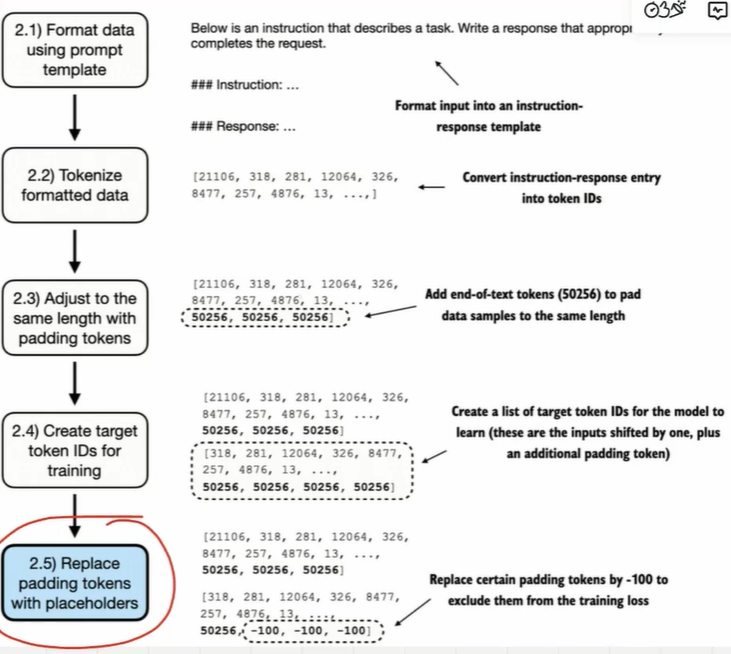


###Tokenizing the formatted data


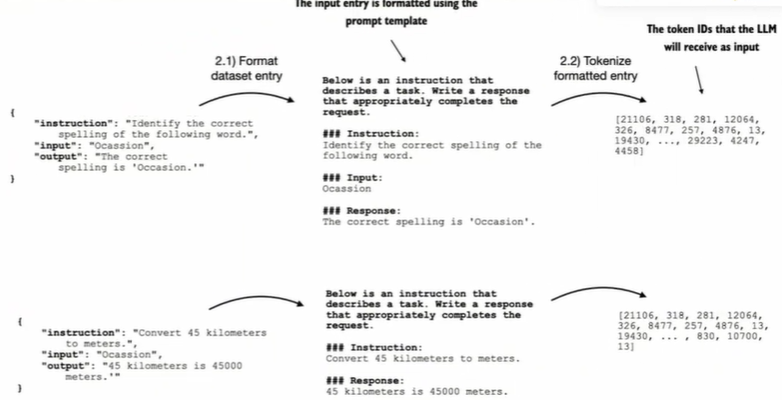

Adjust to the same length with padding tokens:

Here we see that the tokenized output of each entry varied due to the length of the sentence in both the entries varies. But the actual requirement is that we need the length of the tokenized output of each entry irrespective of their length to be of the same length. For this we go to the 3rd step of Padding Tokens.

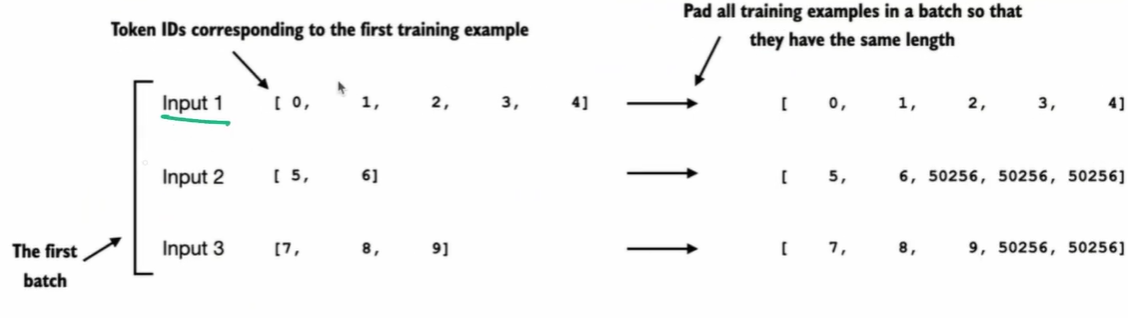

Create Target token ids for training:

Here, to fix the length of all the sentences to the length of longest sentence in a batch we do the below. Create a list of target token IDs for the model to learn (These are the inputs shifted by one, plus an additional padding token).

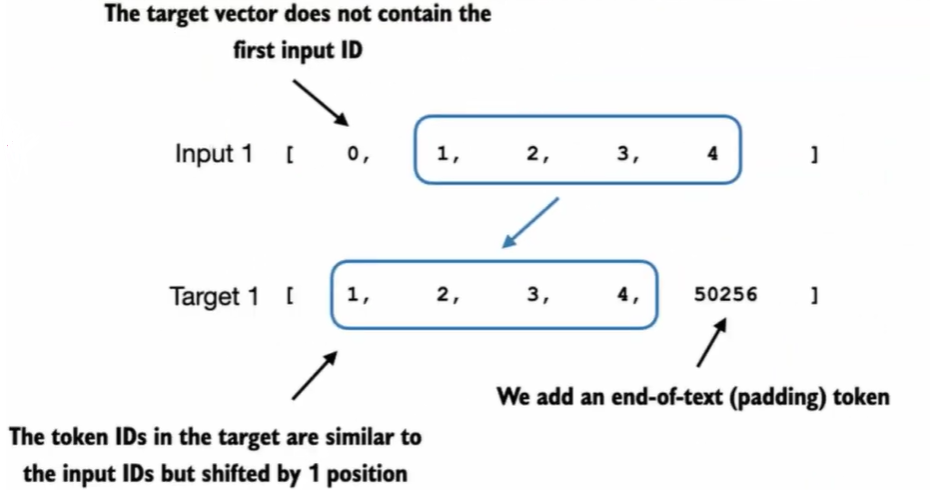

After this step WE would replace the padding tokens with placeholders. Replace certain padding tokens by -100 to exclude. Here we leave the first padding token (50256) and the rest of the padding tokens are replaced.

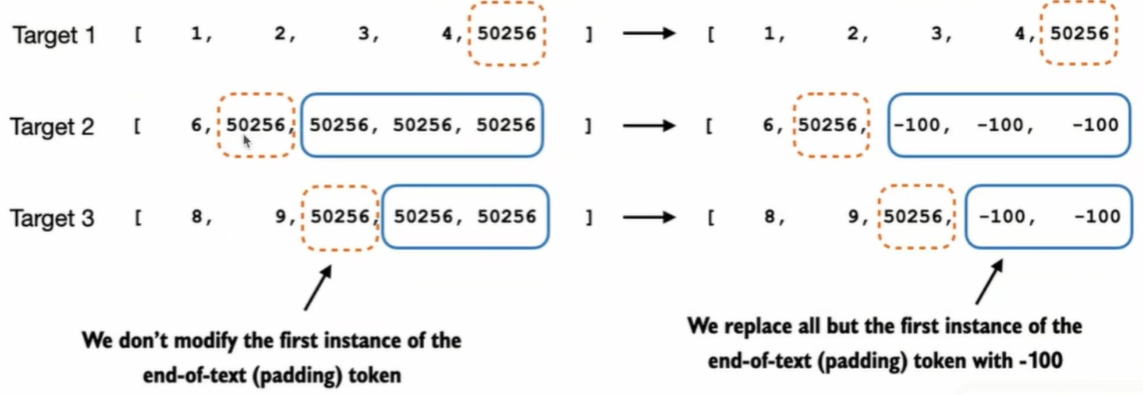

In [ ]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
  def __init__(self, data, tokenizer):
    self.data = data

    #pre-tokenize texts
    self.encoded_texts = []
    for entry in data:
      instruction_plus_input = format_input(entry)
      response_text = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction_plus_input + response_text
      self.encoded_texts.append(
          tokenizer.encode(full_text)
      )

  def __getitem__(self, index):
    return self.encoded_texts[index]

  def __len__(self):
    return len(self.data)

Similar to the approach in chapter 6, we aim to accelerate training by collecting multiple training examples in a batch, which necessitates padding all inputs to a similar length.

As with the previous chapter, we use the <|endoftext|> token as a padding token.

Instead of appending the <|endoftext|> tokens to the text inputs, we can append its token ID to the pre-tokenized inputs directly.

To remind us which token ID we should use, we can use the tokenizer's .encode method on an <|endoftext|> token:

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

In chapter 6, we padded all examples in a dataset to the same length.

Moving on, here, we adopt a more sophisticated approach by developing a custom collate function that we can pass to the data loader.

This custom collate function pads the training examples in each batch to have the same length, while allowing different batches to have different lengths.

This approach minimizes unnecessary padding by only extending sequences to match the longest one in each batch, not the whole dataset.

We can implement the padding process with a custom collate function as follows:

Step 1: Find the longest sequence in the batch

Step 2: Pad and prepare inputs

Step 3: Remove extra padded token added earlier

Step 4: Convert list of inputs to tensor and transfer to target device

In [ ]:
def custom_collate_draft_1(batch,pad_token_id = 50256,device="cpu"):

    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below
    batch_max_length = max(len(item)+1 for item in batch)

    #pad and prepare inputs
    inputs_lst = []

    for item in batch:
      new_item = item.copy()
      #add an <|endoftext|> token
      new_item += [pad_token_id]
      #pad sequences to batch_max_length
      padded = (
          new_item + [pad_token_id] * (batch_max_length - len(new_item))
      )
      # Via padded[:-1], we remove the extra padded token
      # that has been added via the +1 setting in batch_max_length
      # (the extra padding token will be relevant in later codes)
      inputs = torch.tensor(padded[:-1])
      inputs_lst.append(inputs)

    #convert the list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

The custom_collate_draft_1 we implemented is designed to be integrated into a PyTorch DataLoader, but it can also function as a standalone tool.

Here, we use it independently to test and verify that it operates as intended.

Let's try it on three different inputs that we want to assemble into a batch, where each example gets padded to the same length:

In [ ]:
inputs_1 = [0,1,2,3,4]
inputs_2 = [5,6]
inputs_3 = [7,8,9]

batch = (inputs_1, inputs_2, inputs_3)

print(custom_collate_draft_1(batch))

As we can see based on the preceding output, all inputs have been padded to the length of the longest input list, inputs_1 containing 5 token IDs.

So far, we have just implemented our first custom collate function to create batches from lists of inputs.

However, as you learned in previous lessons, we also need to create batches with the target token IDs, corresponding to the batch of input IDs.

These target IDs are crucial because they represent what we want the model to generate and what we need during training to calculate the loss for the weight updates, similar to previous chapters.

## CREATING TARGET TOKEN IDS FOR TRAINING

Similar to the process described for pretraining an LLM, the target token IDs match the input token IDs but are shifted one position to the right.

This setup allows the LLM to learn how to predict the next token in a sequence.

The following updated collate function generates the target token IDs from the input token IDs:

In [ ]:
def custom_collate_draft_2(batch, pad_token_id = 50256, device="cpu"):
  #Find the longest sequence in the batch
  batch_max_length = max(len(item)+1 for item in batch)

  #pad adn prepare inputs
  inputs_lst, targets_lst = [], []

  for item in batch:
    new_item = item.copy()
    #Add an <|endoftext|> token
    new_item += [pad_token_id]
    #pad sequences to max_length
    padded = (new_item + [pad_token_id] * (batch_max_length-len(new_item)))
    inputs = torch.tensor(padded[:-1]) #truncate the last token for inputs
    targets = torch.tensor(padded[1:]) #shift +1 to the right for targets
    inputs_lst.append(inputs)
    targets_lst.append(targets)

  #convert list of inputs to tensor and transfer to target device
  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)
  return inputs_tensor, targets_tensor

Step 1: Truncate the last token for inputs

Step 2: Shift +1 to the right for targets

In [ ]:
inputs_1 = [0,1,2,3,4]
inputs_2 = [5,6]
inputs_3 = [7,8,9]

batch = (inputs_1, inputs_2, inputs_3)

inputs, targets = custom_collate_draft_2(batch)

print(inputs)
print(targets)

The 1st tensor represents inputs.

The 2nd tensor represents the targets

In the next step, we assign a -100 placeholder value to all padding tokens.

This special value allows us to exclude these padding tokens from contributing to the training loss calculation, ensuring that only meaningful data influences model learning.

In classification fine-tuning, we did not have to worry about this since we only trained the model based on the last output token.)

Note that we retain one end-of-text token, ID 50256, in the target list.

This allows the LLM to learn when to generate an end-of-text token in response to instructions, which we use as an indicator that the generated response is complete.

In the following code, we modify our custom collate function to replace tokens with ID 50256 with -100 in the target lists.

Additionally, we introduce an allowed_max_length parameter to optionally limit the length of the samples.

This adjustment will be useful if you plan to work with your own datasets that exceed the 1024- token context size supported by the GPT-2 model.

The code for this updated collate function is as follows:

In [ ]:
def custom_collate_fn(batch, pad_token_id = 50256, ignore_index = -100, allowed_max_length=None, device="cpu"):
  #find the longest sequence in the batch
  batch_max_length = max(len(item)+1 for item in batch)

  #pad and prepare inputs and targets
  inputs_lst, targets_lst = [], []

  for item in batch:
    new_item = item.copy()
    #Add an <|endoftext|> token
    new_item += [pad_token_id]
    #pad sequences to max_length
    padded = (new_item + [pad_token_id]*(batch_max_length - len(new_item)))
    inputs = torch.tensor(padded[:-1]) #truncate the last token for inputs
    targets = torch.tensor(padded[1:]) #shift +1 to the right for targets

    #New: Replace all but the first padding tokens in targets by ignore_index
    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index

    #New: Optionally truncate to maximum sequence length
    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
      targets = targets[:allowed_max_length]

    inputs_lst.append(inputs)
    targets_lst.append(targets)

  #convert list of inputs and targets to tensors and transfer to target device
  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)

  return inputs_tensor, targets_tensor

Step 1: Replace all but the first padding tokens in targets by ignore_index

Step 2: Optionally truncate to maximum sequence length

Again, let's try the collate function on the sample batch that we created earlier to check that it works as intended:

In [ ]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

The modified collate function works as expected, altering the target list by inserting the token ID -100.

What is the logic behind this adjustment? Let's explore the underlying purpose of this modification.

For demonstration purposes, consider the following simple and self-contained example where each output logit can correspond to a potential token from the model's vocabulary.

Here's how we might calculate the cross entropy loss (introduced in chapter 5) during training when the model predicts a sequence of tokens, similar to what we have done in chapter 5 when pretraining the model, or in chapter 6 when finetuning the model for classification:

In [ ]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

Adding an additional token ID will, as we would expect, affect the loss calculation.

In [ ]:
logits_2 = torch.tensor(
    [[-1.0,1.0],
     [-0.5,1.5],
     [-0.5,1.5]] #new 3rd training example
)
targets_2 = torch.tensor([0,1,1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

Now, let's get to the interesting part and see what happens if we replace the third target token ID with -100:

In [ ]:
logits_2 = torch.tensor(
    [[-1.0,1.0],
     [-0.5,1.5],
     [-0.5,1.5]] #new 3rd training example
)
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

Based on this result, we can see that the resulting loss on these 3 training examples is identical to the loss we calculated from the 2 training examples earlier.

In other words, the cross entropy loss function ignored the third entry in the targets_3 vector, the token ID corresponding to -100.

(Interested readers can try to replace the -100 value with another token IDs that is not 0 or 1, and will see that this results in an error.)

So, what's so special about -100 that it's ignored by the cross entropy loss? The default setting of the cross entropy function in PyTorch is cross_entropy(..., ignore_index=-100).

This means that it ignores targets labeled with -100.

In this chapter, we take advantage of this ignore_index to ignore the additional end-oftext (padding) tokens that we used to pad the training examples to have the same length in each batch.

However, we want to keep one 50256 (end-of-text) token ID in the targets because it helps the LLM to learn to generate end-of-text tokens, which we can use as an indicator that a response is complete.

## MASKING TARGET TOKEN IDS

In addition to masking out padding tokens, it is also common to mask out the target token IDs that correspond to the instruction

By masking out the target token IDs that correspond to the instruction, the LLM cross entropy loss is only computed for the generated response target IDs.

By masking out the instruction tokens, the model is trained to focus on generating accurate responses rather than additionally also memorizing instructions, which can help with reducing overfitting.

Currently, researchers are divided on whether masking the instructions is universally beneficial during instruction finetuning.

For instance, a recent paper titled "Instruction Tuning With Loss Over Instructions" demonstrated that not masking the instructions benefits the LLM performance.

In this chapter, we do not apply masking and leave it as an optional exercise for the reader.

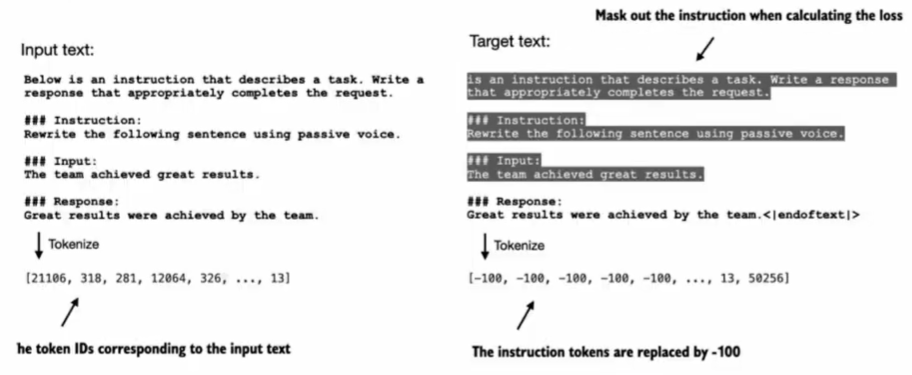

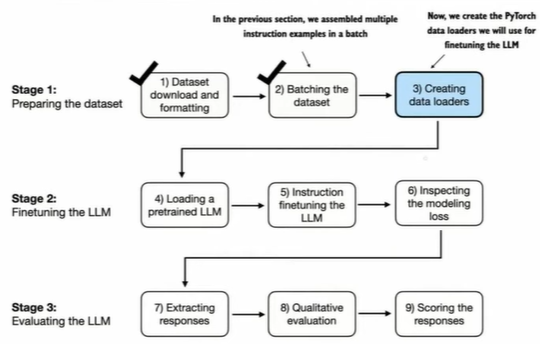

The custom_collate_fn includes code to move the input and target tensors (for example, torch.stack(inputs_lst).to(device)) to a specified device, which can be either "cpu" or "cuda" (for GPUs), or optionally "mps" for Macs with Apple Silicon chips.

In previous chapters, we moved the data onto the target device (for example, the GPU memory when device="cuda") in the main training loop. Having this as part of the collate function offers the advantage of performing this device transfer process as a background process outside the training loop, preventing it from blocking the GPU during model training.

The following code initializes the device variable:

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Note:
# Uncommenting the following lines will allow the code to run on Apple Silicon chips, if applicable,
# which is much faster than on an Apple CPU (as measured on an M3 MacBook Air).
# However, the resulting loss values may be slightly different.

#if torch.cuda.is_available():
#    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
#else:
#    device = torch.device("cpu")

print("Device:", device)

Next, to reuse the chosen device setting in custom_collate_fn when we plug it into the PyTorch DataLoader class later in this section, we use the partial function from Python's functools standard library to create a new version of the function with the device argument pre-filled.

Additionally, we set the allowed_max_length to 1024, which truncates the data to the maximum context length supported by the GPT-2 model we finetune later in this chapter:

In [ ]:
from functools import partial
customized_collate_fn = partial(custom_collate_fn, device = device, allowed_max_length=1024)

Next, we can set up the data loaders as we did in previous chapters, but this time we will use our custom collate function for the batching process:

In [ ]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(train_dataset, batch_size = batch_size, collate_fn = customized_collate_fn,
                          shuffle=True, drop_last=True, num_workers = num_workers)
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=customized_collate_fn,
                        shuffle=False, drop_last=False, num_workers=num_workers)
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=customized_collate_fn,
                        shuffle=False, drop_last=False, num_workers=num_workers)

Let's examine the dimensions of the input and target batches generated by the training loader:

In [ ]:
print("Train loader:")
for inputs, targets in train_loader:
  print(inputs.shape, targets.shape)

In the preceding output, we can see that the first input and target batch have dimensions 8×61, where 8 represents the batch size, and 61 is the number of tokens in each training example in this batch.

The second input and target batch have a different number of tokens, for instance, 76.

As we saw in the preceding code output, thanks to our custom collate function, the data loader is able to create batches of different lengths.

In the next section, we load a pretrained LLM that we can then finetune with this data loader.

# STEP 4: LOADING A PRETRAINED LLM

Before beginning instruction finetuning, we first load a pretrained GPT model,

Instead of using the smallest 124 million parameter model as before, we load the medium-sized model with 355 million parameters.

The reason for this choice is that the 124 million parameter model is too limited in capacity to achieve qualitatively satisfactory results via instruction finetuning.

This is done using the same code as in section 5.5 of chapter 5 and section 6.4 of the previous chapter, except that we now specify "gpt2-medium (355M)" instead of "gpt2-small (124M)".

Please note that executing the code provided below will initiate the download of the medium-sized GPT model, which has a storage requirement of approximately 1.42 gigabytes.

This is roughly three times larger than the storage space needed for the small model:

In [ ]:
from gpt_download import download_and_load_gpt2


BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

Before diving into finetuning the model in the next section, let's take a moment to assess the pretrained LLM's performance on one of the validation tasks by comparing its output to the expected response.

This will give us a baseline understanding of how well the model performs on an instruction-following task right out of the box, prior to finetuning, and will help us appreciate the impact of finetuning later on.

We use the first example from the validation set for this assessment:

In [ ]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

In [ ]:
token_ids= generate(model=model, idx=text_to_token_ids(input_text, tokenizer),
                    max_new_tokens=35, context_size=BASE_CONFIG["context_length"],
                    eos_id=50256)
generated_text = token_ids_to_text(token_ids, tokenizer)

It's important to note that the generate function returns the combined input and output text.

This behavior was convenient in previous chapters since pretrained LLMs are primarily designed as text-completion models, where the input and output are concatenated to create a coherent and legible text.

However, when evaluating the model's performance on a specific task, we often want to focus solely on the model's generated response.

To isolate the model's response text, we need to subtract the length of the input instruction from the start of the generated_text:

In [ ]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

This code snippet removes the input text from the beginning of the generated_text, leaving us with only the model's generated response. The strip() function is then applied to remove any leading or trailing whitespace characters. The output is as follows:

As we can see from the output, the pretrained model is not yet capable of correctly following the given instruction.

While it does create a "Response" section, it simply repeats the original input sentence and part of the instruction, failing to convert the active sentence to passive voice as requested.

In the upcoming section, we implement the finetuning process to improve the model's ability to comprehend and appropriately respond to such requests.